In [32]:
import random
from pathlib import Path
import math
import re

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import tensorflow as tf
from tensorflow.keras import layers, metrics, models, optimizers, activations, losses

from torchvision.datasets import GTSRB

# from google.colab import files, output, runtime

In [33]:
RAW_DIR = "./data/raw"
PROCESSED_DIR = "./data/processed"
LATENT_DIR = "./data/latent"
IMAGE_SIZE = 64
BATCH_SIZE = 128
SEED = 42
DATASET_REPETITIONS = 1
DATASET_SIZE = 25000
MIN_DATA_DIM = 32
EPOCHS = 400
EMA = 0.999
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NOISE_EMBEDDING_SIZE = 128

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
train_dataset = GTSRB(root=RAW_DIR, split="train", download=True)

eligible_indices = []
for idx in range(len(train_dataset)):
    pil_img, _ = train_dataset[idx]
    if min(pil_img.size) >= MIN_DATA_DIM:
        eligible_indices.append(idx)

sample_count = min(DATASET_SIZE, len(eligible_indices))
sample_indices = random.sample(eligible_indices, sample_count)

print(f"Total eligible images: {len(eligible_indices)}")

def preprocess_gtsrb_image(pil_img):
    img = pil_img.convert("RGB")
    img = ImageOps.fit(
        img,
        (IMAGE_SIZE, IMAGE_SIZE),
        method=Image.Resampling.LANCZOS,
        centering=(0.5, 0.5),
    )
    return np.asarray(img, dtype=np.float32) / 255.0

sampled_images = []
for idx in sample_indices:
    pil_img, _ = train_dataset[idx]
    sampled_images.append(preprocess_gtsrb_image(pil_img))

sampled_images = np.stack(sampled_images, axis=0)

train = tf.data.Dataset.from_tensor_slices(sampled_images)
train = train.shuffle(DATASET_SIZE, seed=SEED)
train = train.batch(BATCH_SIZE, drop_remainder=False)
train = train.prefetch(tf.data.AUTOTUNE)
train = train.repeat(DATASET_REPETITIONS)

100%|██████████| 187M/187M [00:03<00:00, 58.7MB/s]


Total eligible images: 22214


In [38]:
@tf.keras.utils.register_keras_serializable()
def sinusoidal_embedding(x):
    frequencies = tf.exp(tf.linspace( tf.math.log(1.0), tf.math.log(1000.0), NOISE_EMBEDDING_SIZE // 2))
    angular_speeds = 2.0 * math.pi * frequencies
    embeddings = tf.concat([tf.sin(angular_speeds * x), tf.cos(angular_speeds * x)], axis=3)
    return embeddings

class UNet:
    def __init__(self, image_size, noise_embedding_size):
        self.image_size = image_size
        self.noise_embedding_size = noise_embedding_size

    def residual_block(self, width):
        def apply(x):
            input_width = x.shape[3]
            if input_width == width:
                residual = x
            else:
                residual = layers.Conv2D(width, kernel_size=1)(x)
            x = layers.BatchNormalization(center=False, scale=False)(x)
            x = layers.Conv2D(width, kernel_size=3, padding="same", activation=activations.swish)(x)
            x = layers.Conv2D(width, kernel_size=3, padding="same")(x)
            x = layers.Add()([x, residual])
            return x

        return apply

    def down_block(self, width, block_depth):
        def apply(x):
            x, skips = x
            for _ in range(block_depth):
                x = self.residual_block(width)(x)
                skips.append(x)
            x = layers.AveragePooling2D(pool_size=2)(x)
            return x

        return apply

    def up_block(self, width, block_depth):
        def apply(x):
            x, skips = x
            x = layers.UpSampling2D(size=2, interpolation="bilinear")(x)
            for _ in range(block_depth):
                x = layers.Concatenate()([x, skips.pop()])
                x = self.residual_block(width)(x)
            return x
        return apply
    
    def build(self):

        noisy_images = layers.Input(shape=(self.image_size, self.image_size, 3))
        x = layers.Conv2D(32, kernel_size=1)(noisy_images)

        noise_variances = layers.Input(shape=(1, 1, 1))
        noise_embedding = layers.Lambda(sinusoidal_embedding, output_shape=(1, 1, self.noise_embedding_size))(noise_variances)
        noise_embedding = layers.UpSampling2D(size=self.image_size, interpolation="nearest")(noise_embedding)

        x = layers.Concatenate()([x, noise_embedding])

        skips = []

        x = self.down_block(64, block_depth=2)([x, skips])
        x = self.down_block(128, block_depth=2)([x, skips])
        x = self.down_block(256, block_depth=2)([x, skips])
        x = self.residual_block(512)(x)
        x = self.residual_block(512)(x)
        x = self.up_block(256, block_depth=2)([x, skips])
        x = self.up_block(128, block_depth=2)([x, skips])
        x = self.up_block(64, block_depth=2)([x, skips])

        x = layers.Conv2D(3, kernel_size=1, kernel_initializer="zeros")(x)
        unet = models.Model([noisy_images, noise_variances], x, name="unet")

        return unet

class DiffusionModel(models.Model):
    def __init__(self, image_size, noise_embedding_size, unet):
        super().__init__()

        self.normalizer = layers.Normalization()
        self.network = unet
        self.ema_network = models.clone_model(self.network)
        self.image_size = image_size
        self.noise_embedding_size = noise_embedding_size

    def diffusion_schedule(self, diffusion_times):
        min_signal_rate = 0.02
        max_signal_rate = 0.95
        start_angle = tf.acos(max_signal_rate)
        end_angle = tf.acos(min_signal_rate)

        diffusion_angles = start_angle + diffusion_times * (end_angle - start_angle)

        signal_rates = tf.cos(diffusion_angles)
        noise_rates = tf.sin(diffusion_angles)

        return noise_rates, signal_rates

    def build(self, input_shape):
        dummy_images = tf.zeros((1, self.image_size, self.image_size, 3))
        dummy_noise = tf.zeros((1, 1, 1, 1))
        _ = self.network([dummy_images, dummy_noise])
        _ = self.ema_network([dummy_images, dummy_noise])
        super().build(input_shape)

    def compile(self, **kwargs):
        super().compile(**kwargs)
        self.noise_loss_tracker = metrics.Mean(name="n_loss")

    @property
    def metrics(self):
        return [self.noise_loss_tracker]

    def denormalize(self, images):
        images = self.normalizer.mean + images * self.normalizer.variance**0.5
        return tf.clip_by_value(images, 0.0, 1.0)

    def denoise(self, noisy_images, noise_rates, signal_rates, training):
        if training:
            network = self.network
        else:
            network = self.ema_network
        pred_noises = network([noisy_images, noise_rates**2], training=training)
        pred_images = (noisy_images - noise_rates * pred_noises) / signal_rates
        return pred_noises, pred_images

    def train_step(self, images):
        images = self.normalizer(images, training=True)
        batch_size = tf.shape(images)[0]
        noises = tf.random.normal(shape=(batch_size, self.image_size, self.image_size, 3))

        diffusion_times = tf.random.uniform(shape=(batch_size, 1, 1, 1), minval=0.0, maxval=1.0)
        noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
        noisy_images = signal_rates * images + noise_rates * noises

        with tf.GradientTape() as tape:
            pred_noises, pred_images = self.denoise(noisy_images, noise_rates, signal_rates, training=True)
            noise_loss = self.loss(noises, pred_noises)

        gradients = tape.gradient(noise_loss, self.network.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.network.trainable_weights))
        self.noise_loss_tracker.update_state(noise_loss)

        for weight, ema_weight in zip(self.network.weights, self.ema_network.weights):
            ema_weight.assign(EMA * ema_weight + (1 - EMA) * weight)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, images):
        images = self.normalizer(images, training=False)
        batch_size = tf.shape(images)[0]
        noises = tf.random.normal(shape=(batch_size, self.image_size, self.image_size, 3))
        diffusion_times = tf.random.uniform(shape=(batch_size, 1, 1, 1), minval=0.0, maxval=1.0)
        noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
        noisy_images = signal_rates * images + noise_rates * noises
        pred_noises, pred_images = self.denoise(noisy_images, noise_rates, signal_rates, training=False)
        noise_loss = self.loss(noises, pred_noises)
        self.noise_loss_tracker.update_state(noise_loss)
        return {m.name: m.result() for m in self.metrics}

    def generate(self, num_images, diffusion_steps, initial_noise=None):
        if initial_noise is None:
            initial_noise = tf.random.normal(shape=(num_images, self.image_size, self.image_size, 3))
        generated_images = self.reverse_diffusion(initial_noise, diffusion_steps)
        generated_images = self.denormalize(generated_images)
        return generated_images

    def reverse_diffusion(self, initial_noise, diffusion_steps):
        num_images = initial_noise.shape[0]
        step_size = 1.0 / diffusion_steps
        current_images = initial_noise
        for step in range(diffusion_steps):
            diffusion_times = tf.ones((num_images, 1, 1, 1)) - step * step_size
            noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
            pred_noises, pred_images = self.denoise(current_images, noise_rates, signal_rates, training=False)
            next_diffusion_times = diffusion_times - step_size
            next_noise_rates, next_signal_rates = self.diffusion_schedule(next_diffusion_times)
            current_images = (next_signal_rates * pred_images + next_noise_rates * pred_noises)
        return pred_images
    
def load_model(weight_path):
    model = DiffusionModel(IMAGE_SIZE, NOISE_EMBEDDING_SIZE, unet)
    model.build((None, IMAGE_SIZE, IMAGE_SIZE, 3))
    model.normalizer.build((None, IMAGE_SIZE, IMAGE_SIZE, 3))
    model.load_weights(str(weight_path))
    return model

adamw = optimizers.AdamW(
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY)

unet_builder = UNet(IMAGE_SIZE, NOISE_EMBEDDING_SIZE)
unet = unet_builder.build()

In [ ]:
diffusion_model = DiffusionModel(IMAGE_SIZE, NOISE_EMBEDDING_SIZE, unet)

diffusion_model.normalizer.adapt(train)

diffusion_model.compile(optimizer=adamw, loss=losses.MeanAbsoluteError())

diffusion_model.build((None, IMAGE_SIZE, IMAGE_SIZE, 3))

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath='weights/epoch_{epoch:03d}.weights.h5',
    save_weights_only=True,
)

history = diffusion_model.fit(train, epochs=EPOCHS, callbacks=[checkpoint_cb])

Epoch 1/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 91s 266ms/step - n_loss: 0.3810
Epoch 2/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1647
Epoch 3/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1485
Epoch 4/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1363
Epoch 5/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1286
Epoch 6/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1235
Epoch 7/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1184
Epoch 8/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1155
Epoch 9/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1118
Epoch 10/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1093
Epoch 11/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1063
Epoch 12/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1052
Epoch 13/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - n_loss: 0.1039
Epoch 14/400
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 1

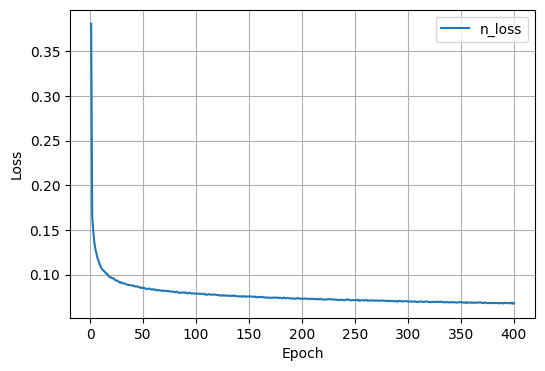

In [7]:
n_loss = history.history.get('n_loss', [])
epochs = range(1, len(n_loss) + 1)
plt.figure(figsize=(6, 4))
plt.plot(epochs, n_loss, label="n_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

out_dir = Path(PROCESSED_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

save_path_loss = out_dir / "loss.png"
plt.savefig(save_path_loss, dpi=150, bbox_inches="tight")
plt.show()

### Display Images from Different Epochs

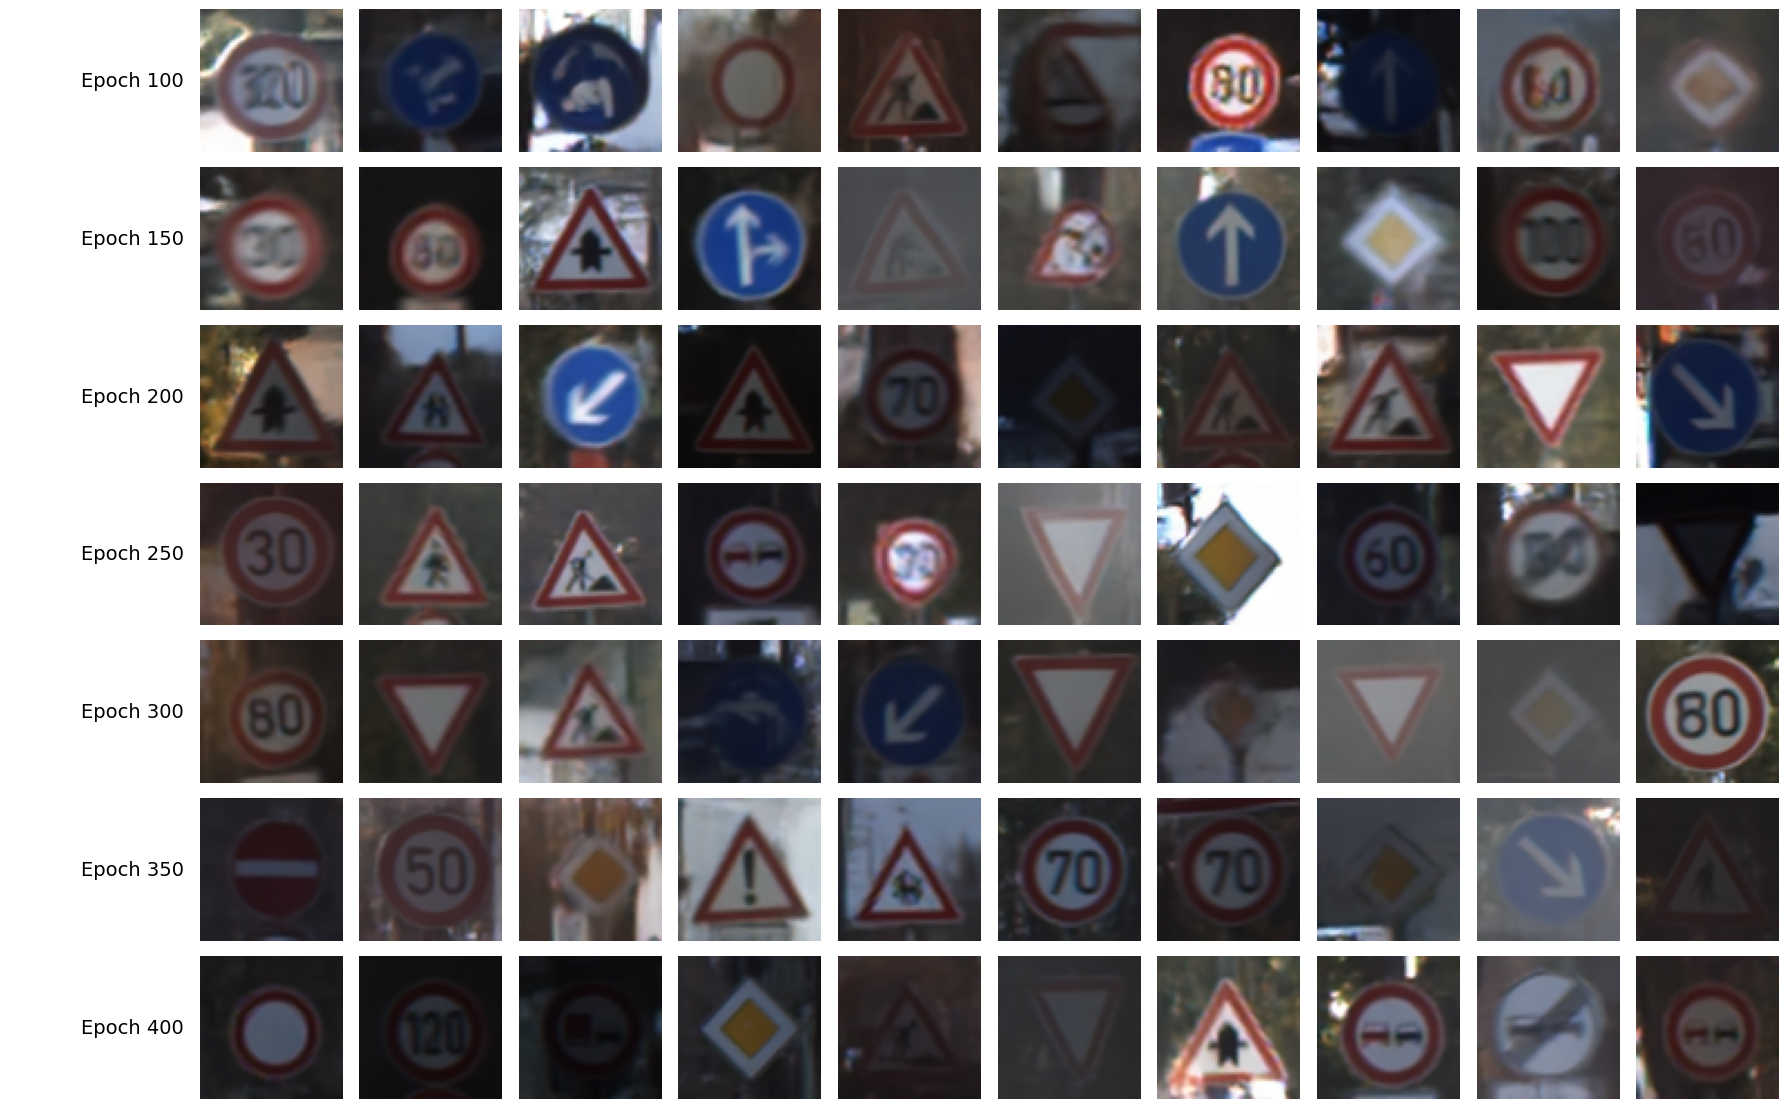

Loaded 7 checkpoints from weights
Saved grid to data/processed/epoch_grids/ds_100_dim_64_epoch_grid.png


In [ ]:
NUM_IMAGES = 10
DIFFUSION_STEPS = 100
EPOCH_RANGE = (100, 400, 50)
EPOCHS_TO_PLOT = None

checkpoint_pattern = "epoch_*.weights.h5"
weights_dir = Path("./weights")
epoch_path_pairs = []

matches = []
matches.extend(weights_dir.glob(checkpoint_pattern))

for p in matches:
    m = re.search(r"epoch[_-]?(\d+)", p.name)
    if m:
        epoch_path_pairs.append((int(m.group(1)), p))

epoch_path_pairs.sort(key=lambda x: x[0])

if not epoch_path_pairs:
    raise FileNotFoundError("No saved weights found.")

available_epochs = [ep for ep, _ in epoch_path_pairs]

if EPOCH_RANGE is not None:
    start, end, step = EPOCH_RANGE
    epoch_path_pairs = [(ep, p) for ep, p in epoch_path_pairs if start <= ep <= end and (ep - start) % step == 0]

if EPOCHS_TO_PLOT is not None:
    wanted = set(EPOCHS_TO_PLOT)
    epoch_path_pairs = [(ep, p) for ep, p in epoch_path_pairs if ep in wanted]

if not epoch_path_pairs:
    raise ValueError(f"No checkpoints left after filtering. Available epochs: {available_epochs}")

out_dir = Path("./data/processed") / "epoch_grids"
out_dir.mkdir(parents=True, exist_ok=True)

fig = plt.figure(figsize=(NUM_IMAGES * 1.6 + 2.0, len(epoch_path_pairs) * 1.6))
gs = fig.add_gridspec(len(epoch_path_pairs), NUM_IMAGES + 1, width_ratios=[1.2] + [1] * NUM_IMAGES)

model = DiffusionModel(IMAGE_SIZE, NOISE_EMBEDDING_SIZE, unet)
model.build((None, IMAGE_SIZE, IMAGE_SIZE, 3))
model.normalizer.build((None, IMAGE_SIZE, IMAGE_SIZE, 3))

loaded_count = 0

for row_index, (epoch_number, weight_path) in enumerate(epoch_path_pairs):
    model.load_weights(str(weight_path))

    generated = model.generate(NUM_IMAGES, DIFFUSION_STEPS).numpy()
    loaded_count += 1

    ax_label = fig.add_subplot(gs[row_index, 0])
    ax_label.axis("off")
    ax_label.text(1.0, 0.5, f"Epoch {epoch_number}", ha="right", va="center", fontsize=14)

    for col_index in range(NUM_IMAGES):
        ax = fig.add_subplot(gs[row_index, col_index + 1])
        ax.imshow(np.clip(generated[col_index], 0.0, 1.0))
        ax.axis("off")

plt.tight_layout()
save_path = out_dir / f"ds_{DIFFUSION_STEPS}_dim_{IMAGE_SIZE}_epoch_grid.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Loaded {loaded_count} checkpoints from {weights_dir}")
print(f"Saved grid to {save_path}")

In [11]:
files.download(save_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Display Generated Images

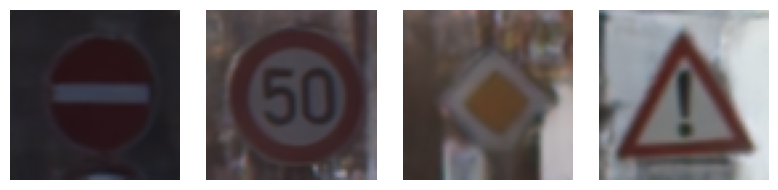

In [ ]:
NUM_IMAGES = 16
DIFFUSION_STEPS = 200
weight_path = "weights/epoch_400.weights.h5"

model = load_model(weight_path)

generated = model.generate(NUM_IMAGES, DIFFUSION_STEPS).numpy()

out_dir = Path(PROCESSED_DIR) / "generated"
out_dir.mkdir(parents=True, exist_ok=True)

cols = 4
rows = math.ceil(NUM_IMAGES / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = axes.flatten()
for ax in axes:
    ax.axis("off")
for i in range(NUM_IMAGES):
    axes[i].imshow(generated[i])
plt.tight_layout()
save_path = out_dir / f"ds_{DIFFUSION_STEPS}_dim_{IMAGE_SIZE}_generated_images.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

### Noise Interpolation

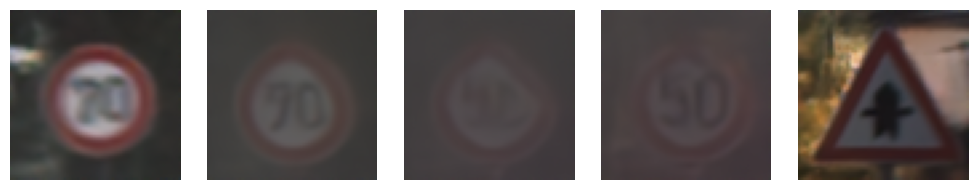

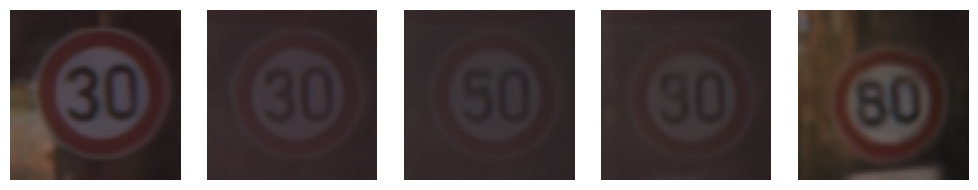

In [ ]:
NUM_IMAGES = 5
DIFFUSION_STEPS = 200
weight_path = "weights/epoch_400.weights.h5"

out_dir = Path(LATENT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

model = load_model(weight_path)

def generate_interpolation(model):
    z1 = tf.random.normal([1, IMAGE_SIZE, IMAGE_SIZE, 3])
    z2 = tf.random.normal([1, IMAGE_SIZE, IMAGE_SIZE, 3])

    generated_images = []

    for alpha in np.linspace(0, 1, NUM_IMAGES):
        z_interp = (1 - alpha) * z1 + alpha * z2
        generated = model.generate(1, DIFFUSION_STEPS, initial_noise=z_interp).numpy()[0]
        generated_images.append(generated)

    cols = NUM_IMAGES
    rows = 1
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()
    for ax in axes:
        ax.axis("off")
    for i in range(NUM_IMAGES):
        axes[i].imshow(generated_images[i])
    plt.tight_layout()
    save_path = out_dir / f"interpolation.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

for _ in range(2):
    generate_interpolation(model)

### Noise Perturbation

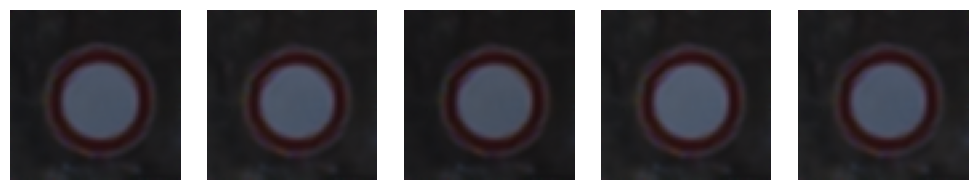

In [40]:
NUM_IMAGES = 5
DIFFUSION_STEPS = 200
weight_path = "weights/epoch_400.weights.h5"

out_dir = Path(LATENT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

model = load_model(weight_path)

base_noise = tf.random.normal([1, IMAGE_SIZE, IMAGE_SIZE, 3])

def generate_perturbation(model):
    generated_images = []

    for _ in range(NUM_IMAGES):
        perturbation = tf.random.normal([1, IMAGE_SIZE, IMAGE_SIZE, 3]) * 0.1
        noise = base_noise + perturbation
        generated = model.generate(1, DIFFUSION_STEPS, initial_noise=noise).numpy()[0]
        generated_images.append(generated)

    cols = NUM_IMAGES
    rows = 1
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()
    for ax in axes:
        ax.axis("off")
    for i in range(NUM_IMAGES):
        axes[i].imshow(generated_images[i])
    plt.tight_layout()
    save_path = out_dir / f"perturbation.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# for _ in range(2):
generate_perturbation(model)